In [1]:
using Pkg
Pkg.activate("C:/Users/ibzja/Documents/UPF_2022_2026/4t/2n_trimestre/Practiques_tutelades/CellBasedModels.jl")
using CellBasedModels 
using GeometryBasics
using Distributions
using GLMakie
Makie.inline!(true)
using CSV, DataFrames, Statistics
using Printf, JLD2


  Activating project at `C:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl`


In [3]:
function springForce(x1, y1, x2, y2, k, l0)
    dx = x2 - x1
    dy = y2 - y1
    r = sqrt(dx^2 + dy^2)
    if r ≈ 0 
        return 0.0, 0.0 
    end  # avoid division by zero
    F = k * (r - l0)  # Hooke’s law
    Fx = F * dx / r
    Fy = F * dy / r
    return Fx, Fy
end

springForce (generic function with 1 method)

In [7]:
beadSpring2D = ABM(2,
    agent = Dict(
        :vx => Float64,
        :vy => Float64,
        :v => Float64,  
        :m => Float64,

        :fx => Float64,
        :fy => Float64,
        :W => Float64,
        :pressure => Float64,
        :group => Int,
        :isConnected => Bool,
        :bead_id => Int,
        :kn => Float64,
        :l0 => Float64
    ),

    # model = Dict(

    #     :Dr_run => Float64,

    #     :ε0 => Float64, #Energy parameters
    #     :ε1 => Float64,
    #     :ε2 => Float64,
    #     :ε3 => Float64,
    #     :K => Float64,
    #     :Nrec => Float64, #Cooperativity
    #     :Ki => Float64, #Dissociation constants
    #     :Ka => Float64,
    #     :τm => Float64, #Methylation adaptation timescale
    #     :α => Float64,      #Total Yp pool
    #     :ωFrec => Float64,     #Basal switching frequency
    #     :Ky => Float64,         #CheA - CheY phosphorylation rate
    #     :Z => Float64,          #CheZ concentration
    #     :Kz => Float64,         #CheZ mediated dephosphorylation rate
    #     :Yy => Float64,         #Basa Yp leak

    #     :DMedium => Float64,
    #     :DSource => Float64,
    #     :delta => Float64,
    # ),

    agentODE = quote

        fx = 0.0
        fy = 0.0
        W = 0.0
        pressure = 0.0

        # Get current group and bead_id
        grp = group
        bid = bead_id

        # Get connected pairs for this group
        connections = GROUP_CONNECTIONS[grp]  # e.g., [(1,2), (2,3), (3,4), (4,1)]

        # Loop over connections
        for (i, j) in connections
            if bid == i
                # This bead is i, connect to j
                j_idx = (grp-1)*4 + j  # global index of bead j
                dx = com.x[j_idx] - x
                dy = com.y[j_idx] - y
                r = sqrt(dx^2 + dy^2)
                if r ≈ 0.0
                    Fx, Fy = 0.0, 0.0
                else
                    F = kn * (r - l0)
                    Fx = F * dx / r
                    Fy = F * dy / r
                end
                fx += Fx
                fy += Fy
                W += sqrt(Fx^2 + Fy^2)
                pressure += sqrt(Fx^2 + Fy^2)

            elseif bid == j
                # This bead is j, connect to i
                i_idx = (grp-1)*4 + i  # global index of bead i
                dx = com.x[i_idx] - x
                dy = com.y[i_idx] - y
                r = sqrt(dx^2 + dy^2)
                if r ≈ 0.0
                    Fx, Fy = 0.0, 0.0
                else
                    F = kn * (r - l0)
                    Fx = F * dx / r
                    Fy = F * dy / r
                end
                fx += Fx
                fy += Fy
                W += sqrt(Fx^2 + Fy^2)
                pressure += sqrt(Fx^2 + Fy^2)
            end
        end

    # Update velocity and position
        dt(vx) = fx / m
        dt(vy) = fy / m
        dt(x) = vx
        dt(y) = vy

    end,     
        

    agentRule = quote

        if x < simBox[1,1]
            x = simBox[1,1]
        elseif x > simBox[1,2]
            x = simBox[1,2]
        end
        
        if y < simBox[2,1]
            y = simBox[2,1]
        elseif y > simBox[2,2]
            y = simBox[2,2]
        end

    end,

    neighborsAlg = CBMNeighbors.CellLinked(cellEdge = 4)
)

PARAMETERS
	x (Float64 agent)
	y (Float64 agent)
	isConnected (Bool agent)
	group (Int64 agent)
	v (Float64 agent)
	fx (Float64 agent)
	vx (Float64 agent)
	fy (Float64 agent)
	m (Float64 agent)
	pressure (Float64 agent)
	vy (Float64 agent)
	W (Float64 agent)
	kn (Float64 agent)
	l0 (Float64 agent)
	bead_id (Int64 agent)


UPDATE RULES
agentRule
 begin
    if x < simBox[1, 1]
        x__ = simBox[1, 1]
    elseif x > simBox[1, 2]
        x__ = simBox[1, 2]
    end
    if y < simBox[2, 1]
        y__ = simBox[2, 1]
    elseif y > simBox[2, 2]
        y__ = simBox[2, 2]
    end
end

agentODE
 begin
    fx__ = 0.0
    fy__ = 0.0
    W__ = 0.0
    pressure__ = 0.0
    grp = group
    bid = bead_id
    connections = GROUP_CONNECTIONS[grp]
    for (i, j) = connections
        if bid == i
            j_idx = (grp - 1) * 4 + j
            dx = com.x[j_idx] - x
            dy = com.y[j_idx] - y
            r = sqrt(dx ^ 2 + dy ^ 2)
            if r ≈ 0.0
                (Fx, Fy) = (0.0, 0.0)
   

In [8]:
com = Community(
    beadSpring2D,
    N=8,
    dt=0.1,
    # simBox = [-20.0 20.0; -20.0 20.0],
    simBox = [-50.0 50.0; -50.0 50.0],
)

m = 1/100
g = 1/10000
d = 1

com.v = 1
com.kn = 10
com.l0 = 1.0

centers_x = rand(Uniform(com.simBox[1,1], com.simBox[1,2]), 2)  #Center of the whole agents
centers_y = rand(Uniform(com.simBox[2,1], com.simBox[2,2]), 2)

offsets = [
    (-0.5, -0.5),  # bead 1
    ( 0.5, -0.5),  # bead 2
    ( 0.5,  0.5),  # bead 3
    (-0.5,  0.5)   # bead 4
]
# Preallocate agent fields that will be indexed
com.group = zeros(Int, com.N)
com.bead_id = zeros(Int, com.N)
com.x = zeros(Float64, com.N)
com.y = zeros(Float64, com.N)


for i in 1:2        #Numero de grups
    for j in 1:4        #Numero de beads per grup
        idx = (i-1)*4 + j  # global agent index
        com.x[idx] = centers_x[i] + offsets[j][1]
        com.y[idx] = centers_y[i] + offsets[j][2]
        com.group[idx] = i
        com.bead_id[idx] = j
    end
end

const GROUP_CONNECTIONS = Dict(
    i => [(1,2), (2,3), (3,4), (4,1)] for i in 1:2
)

Dict{Int64, Vector{Tuple{Int64, Int64}}} with 2 entries:
  2 => [(1, 2), (2, 3), (3, 4), (4, 1)]
  1 => [(1, 2), (2, 3), (3, 4), (4, 1)]

In [9]:
outfile = "bead_spring.jld2"
steps = 10

loadToPlatform!(com, preallocateAgents=8)
# com.mm = zeros(Float64, com.NMedium...)

jldopen(outfile, "w") do file

    # -------------------------
    # Metadata (written once)
    # -------------------------
    meta = JLD2.Group(file, "meta")
    meta["N"] = com.N
    # meta["NMedium"] = com.NMedium
    meta["steps"] = steps

    # -------------------------
    # Main loop
    # -------------------------
    for step in 1:steps
        step!(com)

        stepname = @sprintf("step_%06d", step)
        g = JLD2.Group(file, stepname)

        # Agent-level arrays (length = N)
        g["x"] = copy(com.x)
        g["y"] = copy(com.y)
        g["group"] = copy(com.group)
        g["bead_id"] = copy(com.bead_id)

    end
end


CompositeException: TaskFailedException

    nested task error: MethodError: no method matching setindex!(::Float64, ::Float64, ::Int64)
    Stacktrace:
     [1] macro expansion
       @ c:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl\examples\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W2sZmlsZQ==.jl:63 [inlined]
     [2] macro expansion
       @ C:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl\src\AgentStructure\auxiliar.jl:166 [inlined]
     [3] (::var"#105#threadsfor_fun#47"{var"#105#threadsfor_fun#45#48"{SubArray{Float64, 1, Matrix{Float64}, Tuple{Int64, Base.Slice{Base.OneTo{Int64}}}, true}, SubArray{Float64, 1, Matrix{Float64}, Tuple{Int64, Base.Slice{Base.OneTo{Int64}}}, true}, SubArray{Float64, 1, Matrix{Float64}, Tuple{Int64, Base.Slice{Base.OneTo{Int64}}}, true}, SubArray{Float64, 1, Matrix{Float64}, Tuple{Int64, Base.Slice{Base.OneTo{Int64}}}, true}, SubArray{Float64, 1, Matri

# Plots

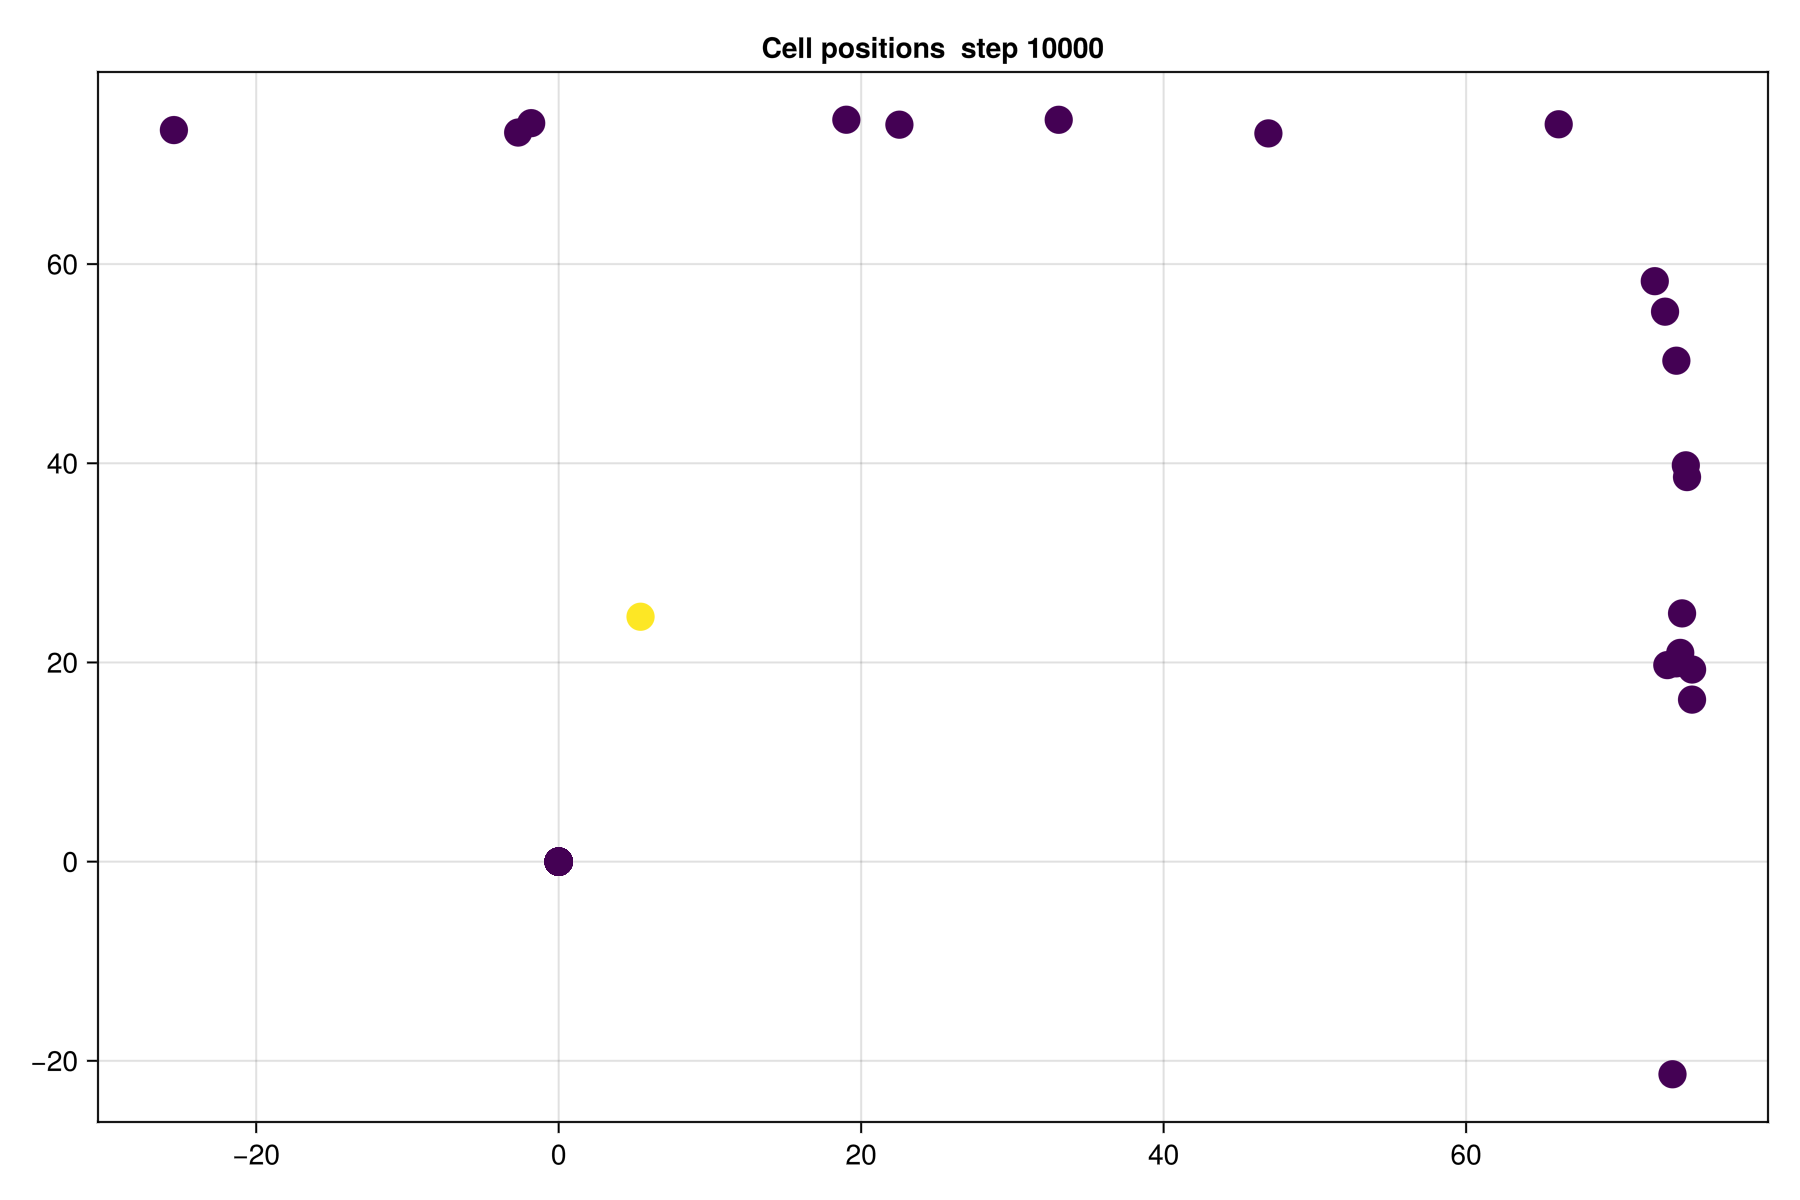

GLMakie.Screen(...)

In [ ]:
fig = Figure(size = (900,600))
ax = Axis(fig[1,1], title ="Cell positions  step 10000")

jldopen("bead_spring.jld2", "r") do file
    g = file[@sprintf("step_%06d", steps)]     #Plot carrega les posicions de totes les cèl·lules en un punt concret. 

    x = g["x"]
    y = g["y"]
    group = g["group"]   # 84 elements: group[i] = 1–21
    bead_id = g["bead_id"]


    scatter!(ax, x, y, markersize = 20, color = s)
end
display(fig)


